# Modèle 4 — MLP (Deep Learning)

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import os

# Deep Learning
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

# Métriques sklearn
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, roc_auc_score, confusion_matrix,
    roc_curve, mean_absolute_error,
    mean_squared_error, r2_score
)

RANDOM_STATE = 42

# Fixation complète de tous les seeds pour reproductibilité totale
import random
import os
random.seed(RANDOM_STATE)
np.random.seed(RANDOM_STATE)
tf.random.set_seed(RANDOM_STATE)
os.environ['PYTHONHASHSEED']       = str(RANDOM_STATE)
os.environ['TF_DETERMINISTIC_OPS'] = '1'   # Opérations déterministes GPU/CPU

os.makedirs('../models', exist_ok=True)
os.makedirs('../results', exist_ok=True)

print(f"Imports OK")
print(f"   TensorFlow version : {tf.__version__}")

Imports OK
   TensorFlow version : 2.21.0


## Chargement des données preprocessées


In [2]:
X_train = np.load('../data/processed/X_train.npy')
X_test  = np.load('../data/processed/X_test.npy')

# Classification — données rééquilibrées par undersampling
X_train_under     = np.load('../data/processed/X_train_under.npy')
y_train_clf_under = np.load('../data/processed/y_train_clf_under.npy')

# Labels originaux (pour régression)
y_train_clf = np.load('../data/processed/y_train_clf.npy')
y_test_clf  = np.load('../data/processed/y_test_clf.npy')
y_train_reg = np.load('../data/processed/y_train_reg.npy')
y_test_reg  = np.load('../data/processed/y_test_reg.npy')

feature_names = pd.read_csv('../data/processed/feature_names.csv')['0'].tolist()

# Calcul du poids pour les classes déséquilibrées
print(f"Données chargées")
print(f"   X_train         : {X_train.shape} (original)")
print(f"   X_train_under   : {X_train_under.shape} (rééquilibré 50/50)")
print(f"   X_test          : {X_test.shape}")
print(f"   Churners train_under : {y_train_clf_under.sum()} ({y_train_clf_under.mean()*100:.1f}%)")
print(f"   Churners test        : {y_test_clf.sum()} ({y_test_clf.mean()*100:.1f}%)")

Données chargées
   X_train         : (8000, 51) (original)
   X_train_under   : (1634, 51) (rééquilibré 50/50)
   X_test          : (2000, 51)
   Churners train_under : 817 (50.0%)
   Churners test        : 204 (10.2%)


## Tâche 1 — Architecture du MLP Classification


In [3]:
# TÂCHE 1 — CLASSIFICATION MLP

def build_mlp_classifier(input_dim):
    model = keras.Sequential([
        layers.Input(shape=(input_dim,)),
        
        # Couche 1
        layers.Dense(128, activation='relu'),
        layers.Dropout(0.3),
        
        # Couche 2
        layers.Dense(64, activation='relu'),
        layers.Dropout(0.2),
        
        # Couche 3
        layers.Dense(32, activation='relu'),
        
        # Sortie
        layers.Dense(1, activation='sigmoid')
    ])
    
    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=0.001),
        loss='binary_crossentropy',
        metrics=['accuracy', 
                 keras.metrics.AUC(name='auc'),
                 keras.metrics.Recall(name='recall'),
                 keras.metrics.Precision(name='precision')]
    )
    return model

# Construction
mlp_clf = build_mlp_classifier(X_train_under.shape[1])
mlp_clf.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 128)            │         6,656 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 17,025 (66.50 KB)

 Trainable params: 17,025 (66.50 KB)

 Non-trainable params: 0 (0.00 B)

In [4]:
# Callbacks
early_stop = EarlyStopping(
    monitor='val_auc',
    patience=10,
    restore_best_weights=True,
    mode='max'
)

reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=5,
    min_lr=1e-6
)

# Entraînement
# Reset seed juste avant le fit pour garantir reproductibilité
tf.random.set_seed(RANDOM_STATE)
np.random.seed(RANDOM_STATE)

history = mlp_clf.fit(
    X_train_under, y_train_clf_under,   # données équilibrées 50/50
    epochs=100,
    batch_size=64,                       # batch réduit (1638 samples)
    validation_split=0.2,
    # class_weight supprimé — données déjà équilibrées par undersampling
    callbacks=[early_stop, reduce_lr],
    verbose=1
)

print(f"\n Entraînement terminé !")
print(f"   Epochs effectuées : {len(history.history['loss'])}")

Epoch 1/100
21/21 ━━━━━━━━━━━━━━━━━━━━ 2s 18ms/step - accuracy: 0.5402 - auc: 0.5125 - loss: 0.7079 - precision: 0.3874 - recall: 0.3898 - val_accuracy: 0.0000e+00 - val_auc: 0.0000e+00 - val_loss: 1.0311 - val_precision: 0.0000e+00 - val_recall: 0.0000e+00 - learning_rate: 0.0010
Epoch 2/100
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.6236 - auc: 0.5537 - loss: 0.6601 - precision: 0.4375 - recall: 0.0143 - val_accuracy: 0.0061 - val_auc: 0.0000e+00 - val_loss: 0.9303 - val_precision: 1.0000 - val_recall: 0.0061 - learning_rate: 0.0010
Epoch 3/100
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.6350 - auc: 0.6165 - loss: 0.6421 - precision: 0.5970 - recall: 0.0816 - val_accuracy: 0.0581 - val_auc: 0.0000e+00 - val_loss: 0.8932 - val_precision: 1.0000 - val_recall: 0.0581 - learning_rate: 0.0010
Epoch 4/100
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.6519 - auc: 0.6648 - loss: 0.6249 - precision: 0.6423 - recall: 0.1612 - val_accuracy: 0.1865 - val_auc: 0.0000e+00

## Courbes d'apprentissage


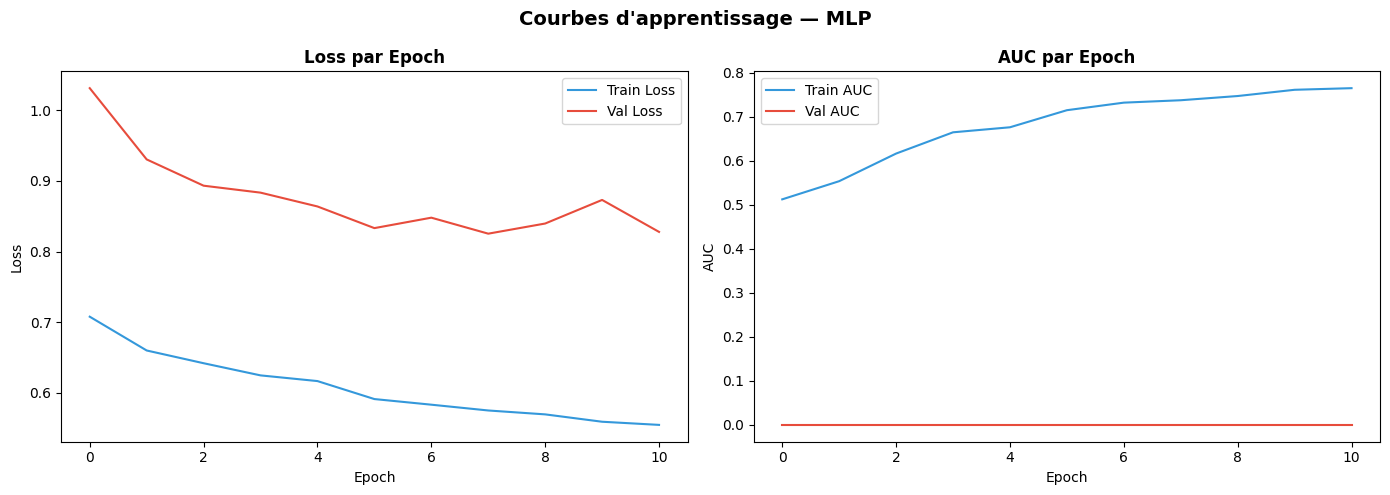

In [5]:
# COURBES D'APPRENTISSAGE

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Loss
axes[0].plot(history.history['loss'], 
             label='Train Loss', color='#3498db')
axes[0].plot(history.history['val_loss'], 
             label='Val Loss', color='#e74c3c')
axes[0].set_title('Loss par Epoch', fontweight='bold')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].legend()

# AUC
axes[1].plot(history.history['auc'], 
             label='Train AUC', color='#3498db')
axes[1].plot(history.history['val_auc'], 
             label='Val AUC', color='#e74c3c')
axes[1].set_title('AUC par Epoch', fontweight='bold')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('AUC')
axes[1].legend()

plt.suptitle('Courbes d\'apprentissage — MLP', 
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('../results/mlp_learning_curves.png', dpi=150)
plt.show()

In [6]:
# ÉVALUATION CLASSIFICATION

y_proba_clf = mlp_clf.predict(X_test).flatten()

# Seuil optimal via courbe ROC
from sklearn.metrics import roc_curve
fpr, tpr, thresholds = roc_curve(y_test_clf, y_proba_clf)
optimal_idx = np.argmax(tpr - fpr)
optimal_threshold = thresholds[optimal_idx]
print(f"Seuil optimal : {optimal_threshold:.4f}")

# Prédiction avec seuil ajusté
y_pred_clf = (y_proba_clf >= optimal_threshold).astype(int)

print(f"\nRésultats — MLP (Classification)")
print(f"   Accuracy  : {accuracy_score(y_test_clf, y_pred_clf):.4f}")
print(f"   Precision : {precision_score(y_test_clf, y_pred_clf):.4f}")
print(f"   Recall    : {recall_score(y_test_clf, y_pred_clf):.4f}")
print(f"   F1-Score  : {f1_score(y_test_clf, y_pred_clf):.4f}")
print(f"   ROC-AUC   : {roc_auc_score(y_test_clf, y_proba_clf):.4f}")

63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
Seuil optimal : 0.3669

Résultats — MLP (Classification)
   Accuracy  : 0.6445
   Precision : 0.1353
   Recall    : 0.4608
   F1-Score  : 0.2091
   ROC-AUC   : 0.5596


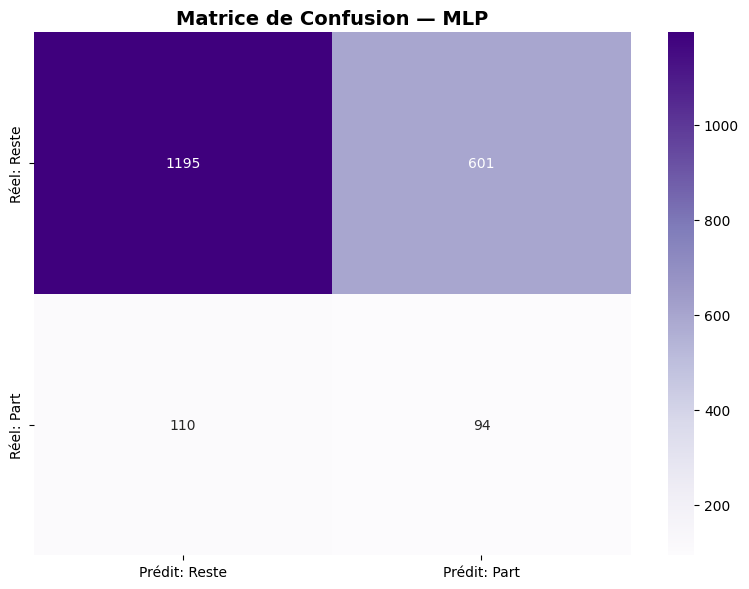


Analyse :
   TN : 1195 | FP : 601
   FN : 110  | TP : 94 

 Comparaison tous les modèles :
   LR  → FN=71,  TP=133
   RF  → FN=111, TP=93
   XGB → FN=165, TP=39
   MLP → FN=110, TP=94


In [7]:
# MATRICE DE CONFUSION

cm = confusion_matrix(y_test_clf, y_pred_clf)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Purples',
            xticklabels=['Prédit: Reste', 'Prédit: Part'],
            yticklabels=['Réel: Reste', 'Réel: Part'])
plt.title('Matrice de Confusion — MLP',
          fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('../results/mlp_confusion_matrix.png', dpi=150)
plt.show()

tn, fp, fn, tp = cm.ravel()
print(f"\nAnalyse :")
print(f"   TN : {tn} | FP : {fp}")
print(f"   FN : {fn}  | TP : {tp} ")
print(f"\n Comparaison tous les modèles :")
print(f"   LR  → FN=71,  TP=133")
print(f"   RF  → FN=111, TP=93")
print(f"   XGB → FN=165, TP=39")
print(f"   MLP → FN={fn}, TP={tp}")

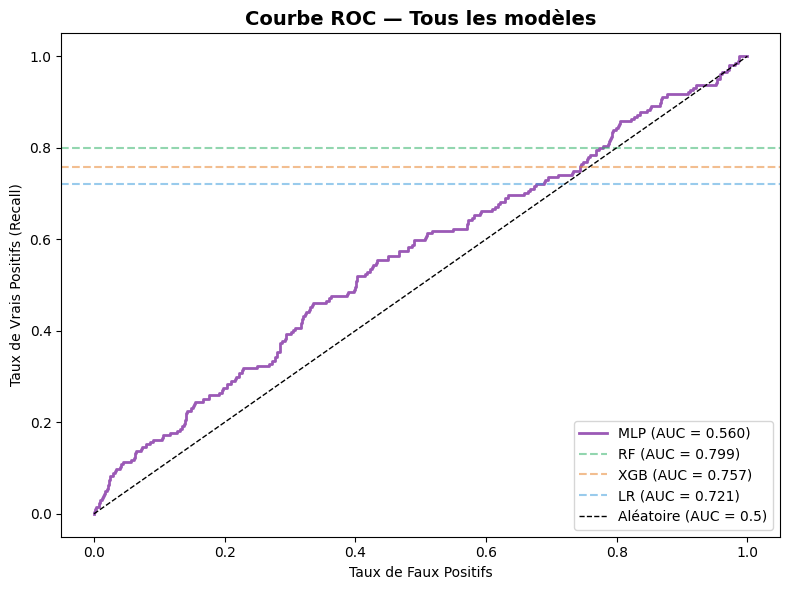

In [8]:
# COURBE ROC FINALE — Tous les modèles

fpr, tpr, _ = roc_curve(y_test_clf, y_proba_clf)
auc = roc_auc_score(y_test_clf, y_proba_clf)

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='#9b59b6', linewidth=2,
         label=f'MLP (AUC = {auc:.3f})')
plt.axhline(y=0.7993, color='#27ae60', linestyle='--',
            alpha=0.5, label='RF (AUC = 0.799)')
plt.axhline(y=0.7570, color='#e67e22', linestyle='--',
            alpha=0.5, label='XGB (AUC = 0.757)')
plt.axhline(y=0.7212, color='#3498db', linestyle='--',
            alpha=0.5, label='LR (AUC = 0.721)')
plt.plot([0, 1], [0, 1], 'k--', linewidth=1,
         label='Aléatoire (AUC = 0.5)')
plt.xlabel('Taux de Faux Positifs')
plt.ylabel('Taux de Vrais Positifs (Recall)')
plt.title('Courbe ROC — Tous les modèles',
          fontsize=14, fontweight='bold')
plt.legend()
plt.tight_layout()
plt.savefig('../results/mlp_roc_curve.png', dpi=150)
plt.show()

## Tâche 2 — Régression du Revenu à Risque


In [9]:
# TÂCHE 2 — RÉGRESSION MLP

def build_mlp_regressor(input_dim):
    model = keras.Sequential([
        layers.Input(shape=(input_dim,)),
        layers.Dense(128, activation='relu'),
        layers.Dropout(0.3),
        layers.Dense(64, activation='relu'),
        layers.Dropout(0.2),
        layers.Dense(32, activation='relu'),
        layers.Dense(1, activation='linear')  # Sortie continue
    ])
    
    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=0.001),
        loss='mse',
        metrics=['mae']
    )
    return model

mlp_reg = build_mlp_regressor(X_train.shape[1])

early_stop_reg = EarlyStopping(
    monitor='val_loss',
    patience=10,
    restore_best_weights=True
)

history_reg = mlp_reg.fit(
    X_train, y_train_reg,
    epochs=100,
    batch_size=256,
    validation_split=0.2,
    callbacks=[early_stop_reg],
    verbose=1
)

y_pred_reg = mlp_reg.predict(X_test).flatten()
y_pred_reg = np.maximum(y_pred_reg, 0)

mae  = mean_absolute_error(y_test_reg, y_pred_reg)
rmse = np.sqrt(mean_squared_error(y_test_reg, y_pred_reg))
r2   = r2_score(y_test_reg, y_pred_reg)

print(f"\n Résultats — MLP Regression")
print(f"   MAE  : {mae:.2f} €")
print(f"   RMSE : {rmse:.2f} €")
print(f"   R²   : {r2:.4f}")
print(f"\n Comparaison tous les modèles :")
print(f"   Ridge → MAE=156.11€, R²=0.0533")
print(f"   RF    → MAE=145.39€, R²=0.0612")
print(f"   XGB   → MAE=158.61€, R²=-0.0024")
print(f"   MLP   → MAE={mae:.2f}€,  R²={r2:.4f}")

Epoch 1/100
25/25 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 173441.5625 - mae: 87.6821 - val_loss: 178380.8438 - val_mae: 94.8133
Epoch 2/100
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 171949.7344 - mae: 93.6270 - val_loss: 175449.2656 - val_mae: 106.0067
Epoch 3/100
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 167183.9531 - mae: 117.9802 - val_loss: 167936.7656 - val_mae: 146.7922
Epoch 4/100
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 162322.7969 - mae: 163.8348 - val_loss: 164504.9062 - val_mae: 170.3161
Epoch 5/100
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 159489.7656 - mae: 167.8592 - val_loss: 162621.2656 - val_mae: 167.8647
Epoch 6/100
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 157515.0156 - mae: 166.7998 - val_loss: 160930.1562 - val_mae: 168.0010
Epoch 7/100
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 156232.1406 - mae: 165.7557 - val_loss: 159622.8594 - val_mae: 164.4790
Epoch 8/100
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 155225.6875 - mae: 161.7921

In [10]:
# SAUVEGARDE

# Sauvegarde MLP au format keras
mlp_clf.save('../models/mlp_classification.keras')
mlp_reg.save('../models/mlp_regression.keras')

results_clf = {
    'model'    : 'MLP',
    'accuracy' : accuracy_score(y_test_clf, y_pred_clf),
    'precision': precision_score(y_test_clf, y_pred_clf),
    'recall'   : recall_score(y_test_clf, y_pred_clf),
    'f1'       : f1_score(y_test_clf, y_pred_clf),
    'roc_auc'  : roc_auc_score(y_test_clf, y_proba_clf)
}

results_reg = {
    'model': 'MLP Regression',
    'mae' : mae,
    'rmse': rmse,
    'r2'  : r2
}

pd.DataFrame([results_clf]).to_csv('../results/mlp_clf_results.csv', index=False)
pd.DataFrame([results_reg]).to_csv('../results/mlp_reg_results.csv', index=False)

print("Modèles sauvegardés dans ../models/")
print("Résultats sauvegardés dans ../results/")
print(f"\n Résumé Classification :")
for k, v in results_clf.items():
    if k != 'model':
        print(f"   {k:10} : {v:.4f}")

Modèles sauvegardés dans ../models/
Résultats sauvegardés dans ../results/

 Résumé Classification :
   accuracy   : 0.6445
   precision  : 0.1353
   recall     : 0.4608
   f1         : 0.2091
   roc_auc    : 0.5596


## Synthèse — MLP (Deep Learning)
